# 3 — TabPFN-3

This notebook trains and evaluates TabPFN-3, which represents the emerging class of tabular foundation models. Unlike XGBoost and AutoGluon, TabPFN does not learn from the training data in the traditional sense — it was pre-trained once by its creators on millions of synthetic datasets, and applies that general understanding to new problems at inference time.

**How TabPFN works:**

1. When `fit()` is called, TabPFN simply stores the training data — no computation happens.
2. When `predict()` is called, the test company is appended to the training data with an unknown rating.
3. The entire dataset is passed through a transformer, which uses attention to compare every row with every other row.
4. The output is a probability distribution over the 10 rating classes — the class with the highest probability becomes the prediction.

This notebook also runs an experiment over the `n_estimators` parameter to determine the optimal configuration.

## Setup

Clone the repository and import project modules. A GPU is recommended for TabPFN

In [ ]:
import os, sys

if not os.path.isdir("src"):
    !git clone https://github.com/andreasz24/Thesis-Artifact.git
    %cd Thesis-Artifact
    !pip install -r requirements.txt --quiet

sys.path.insert(0, os.getcwd())
print("Ready! Working directory:", os.getcwd())

Ready! Working directory: /content/Thesis-Artifact


## TabPFN API token

TabPFN-3 requires a one-time license acceptance to download the model weights.

In [ ]:
import os
# Paste your TabPFN API key between the quotes
os.environ['TABPFN_TOKEN'] = ''

## Load the train/test split

The same preprocessed split used by XGBoost is loaded here, ensuring a fair comparison. If `splits.pkl` doesn't exist, it is created automatically.

In [ ]:
import os, pandas as pd
from src import data, models, evaluation, plotting, config

# If splits.pkl doesn't exist yet, create it automatically
if not os.path.exists(config.SPLITS_PATH):
    print("splits.pkl not found — running preprocessing first...")
    X_train, X_test, y_train, y_test = data.build_splits()
else:
    X_train, X_test, y_train, y_test = data.load_splits()

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (6212, 16) | Test: (1593, 16)


## Device check

TabPFN runs significantly faster on GPU. The cell below checks which device is available.

In [ ]:
device = models.get_device()
print(f'Device: {device}')
if device == 'cpu':
    print('WARNING: No GPU detected. TabPFN will be slow.')
    print('Enable GPU in Colab: Runtime > Change runtime type > GPU')

Device: cpu
Enable GPU in Colab: Runtime > Change runtime type > GPU


## The `n_estimators` experiment

The `n_estimators` parameter controls how many independent forward passes are performed through the transformer. Each pass uses a different random configuration (such as a different ordering of the data rows), which produces a slightly different probability distribution over the rating classes. The final prediction is the average of all these distributions.

The idea is similar to ensembling: by averaging multiple slightly different views of the data, the model should produce more stable and accurate predictions.

We test `n_estimators` ∈ {1, 2, 4, 8, 16} — a doubling sequence that makes it easy to see where the returns diminish:

- **1** = single pass, no ensembling (baseline)
- **2** = minimal ensembling, biggest marginal gain expected here
- **4** = where most benefit typically concentrates
- **8** = likely near plateau for 16 features
- **16** = one estimator per feature — expected diminishing returns

### Running the sweep

For each value of `n_estimators`, TabPFN is fitted and evaluated on the test set. Accuracy, F1 macro, F1 weighted, fit time, and inference time are recorded.

In [ ]:
results_df = models.run_tabpfn_sweep(X_train, y_train, X_test, y_test)
results_df.to_csv(config.OUTPUTS_DIR/'tabpfn3_estimators_results.csv', index=False)
results_df


--------------------------------------------------
  n_estimators = 1
--------------------------------------------------


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

  Accuracy   : 0.4896
  F1 Macro   : 0.2671
  Fit time   : 9.07s | Infer: 87.95s

--------------------------------------------------
  n_estimators = 2
--------------------------------------------------
  Accuracy   : 0.4821
  F1 Macro   : 0.2513
  Fit time   : 0.73s | Infer: 150.22s

--------------------------------------------------
  n_estimators = 4
--------------------------------------------------
  Accuracy   : 0.4815
  F1 Macro   : 0.2538
  Fit time   : 1.06s | Infer: 298.46s

--------------------------------------------------
  n_estimators = 8
--------------------------------------------------
  Accuracy   : 0.4815
  F1 Macro   : 0.2545
  Fit time   : 0.70s | Infer: 600.52s

--------------------------------------------------
  n_estimators = 16
--------------------------------------------------
  Accuracy   : 0.4746
  F1 Macro   : 0.2500
  Fit time   : 0.89s | Infer: 1188.81s


,n_estimators,accuracy,f1_macro,f1_weighted,fit_time_s,inference_time_s,total_time_s
0,1,0.4896,0.2671,0.4715,9.07,87.95,97.01
1,2,0.4821,0.2513,0.4624,0.73,150.22,150.96
2,4,0.4815,0.2538,0.4628,1.06,298.46,299.52
3,8,0.4815,0.2545,0.4628,0.70,600.52,601.23
4,16,0.4746,0.2500,0.4566,0.89,1188.81,1189.69


### Interpreting the results

The results reveal a counterintuitive pattern: performance is **highest at `n_estimators=1`** and declines monotonically as more estimators are added. This is the opposite of the general expectation that ensembling improves accuracy.

The explanation lies in the dimensionality of the dataset. With only 16 features, each estimator already achieves near-complete coverage of the feature space in a single pass through the transformer. There is little unexplored variation for additional estimators to capture. Rather than discovering new patterns, each additional estimator introduces a slightly different variation that, when averaged, marginally reduces performance rather than improving it.

This is an important practical finding: researchers working with similarly low-dimensional tabular data should not assume that more estimators are always better.

### Performance and inference time plots

The left plot shows all three metrics across the `n_estimators` range. The right plot shows how inference time scales linearly with the number of estimators — each additional estimator adds one more forward pass through the transformer.

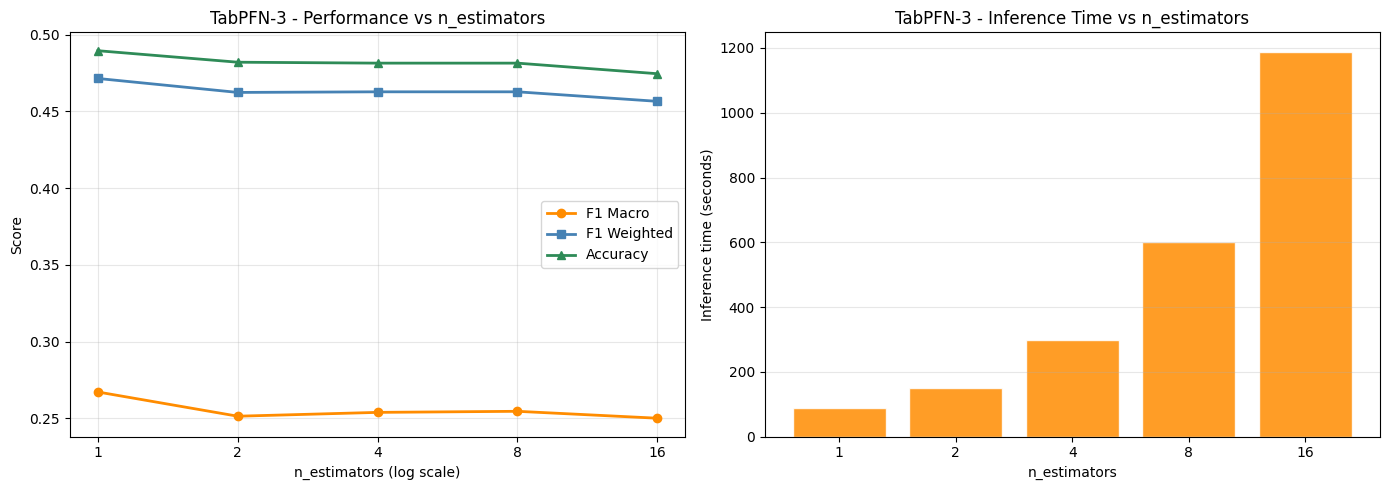

Saved performance plot -> /content/Thesis-Artifact/outputs/tabpfn3_estimators_plot.png


In [ ]:
plotting.plot_tabpfn_sweep(results_df,
    save_path=config.OUTPUTS_DIR/'tabpfn3_estimators_plot.png')

### Marginal gain per estimator step

The chart below shows the incremental change in F1 macro at each step. This makes it easy to see exactly where the plateau is — and in this case, the first step (from 1 to 2) already shows a decline.

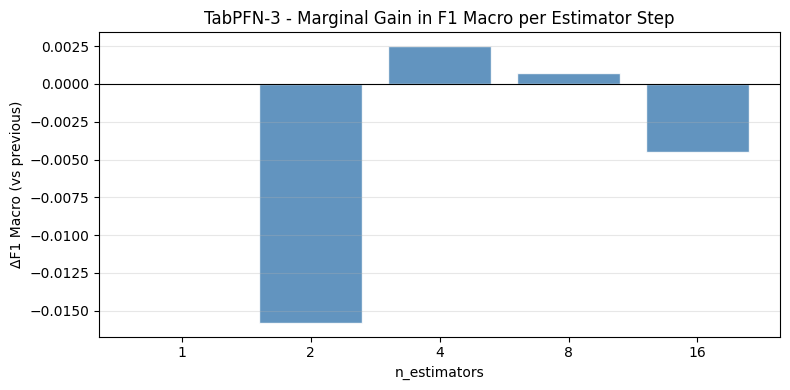

Saved marginal gain plot -> /content/Thesis-Artifact/outputs/tabpfn3_marginal_gain.png


In [ ]:
plotting.plot_tabpfn_marginal_gain(results_df,
    save_path=config.OUTPUTS_DIR/'tabpfn3_marginal_gain.png')

## Final evaluation with the best configuration

Based on the sweep results, the `n_estimators` value with the highest F1 macro is selected as the optimal configuration. The model is retrained with this setting and fully evaluated — including the per-class report, confusion matrix, and probability outputs.

In [ ]:
best_n = int(results_df.loc[results_df['f1_macro'].idxmax(), 'n_estimators'])
print(f'Best n_estimators by F1 macro: {best_n}')

clf, results, y_pred = models.train_tabpfn_best(
    X_train, y_train, X_test, y_test, best_n)
evaluation.print_metrics(f'TabPFN-3 (n_estimators={best_n})', results,
    results['fit_time_s'], results['inference_time_s'], len(X_test))

Best n_estimators by F1 macro: 1

-- TabPFN-3 (n_estimators=1) Results ---------------
  Accuracy      : 0.4896
  F1 (macro)    : 0.2671
  F1 (weighted) : 0.4715
  Training time : 0.65s
  Inference time: 151.9247s  (1593 samples)
--------------------------------------------------


## Per-class report

TabPFN-3 achieves its strongest performance on the same well-populated classes as XGBoost: B, BBB, and A. The rarest classes (C, CC, AAA) again score zero — this limitation is shared across all three models and reflects the class imbalance in the dataset rather than a model-specific weakness.

Compared to XGBoost, TabPFN-3 shows improvements in CCC recall (0.18 vs 0.07) and BBB recall (0.62 vs 0.54), suggesting it is somewhat better at distinguishing the mid-range classes.

In [ ]:
print(evaluation.per_class_report(y_test, y_pred))

              precision    recall  f1-score   support

           C       0.00      0.00      0.00         2
          CC       0.00      0.00      0.00         8
         CCC       0.40      0.18      0.25        56
           B       0.55      0.63      0.59       206
          BB       0.45      0.45      0.45       289
         BBB       0.49      0.61      0.54       501
           A       0.53      0.49      0.51       406
          AA       0.14      0.04      0.07       112
         AAA       0.00      0.00      0.00        13

    accuracy                           0.49      1593
   macro avg       0.28      0.27      0.27      1593
weighted avg       0.47      0.49      0.47      1593



## Confusion matrix

The confusion matrix reveals a strong diagonal structure, with off-diagonal mass concentrated in adjacent rating classes. This is an encouraging pattern — when TabPFN makes errors, they tend to be small ones (misclassifying into a neighbouring class rather than a distant one).

At the critical investment-grade / speculative-grade boundary (BBB vs BB), errors are asymmetric: speculative-grade companies are more frequently pushed above the boundary into investment grade than the other way around. This means the model tends to overestimate creditworthiness at this boundary — a pattern with real practical consequences.

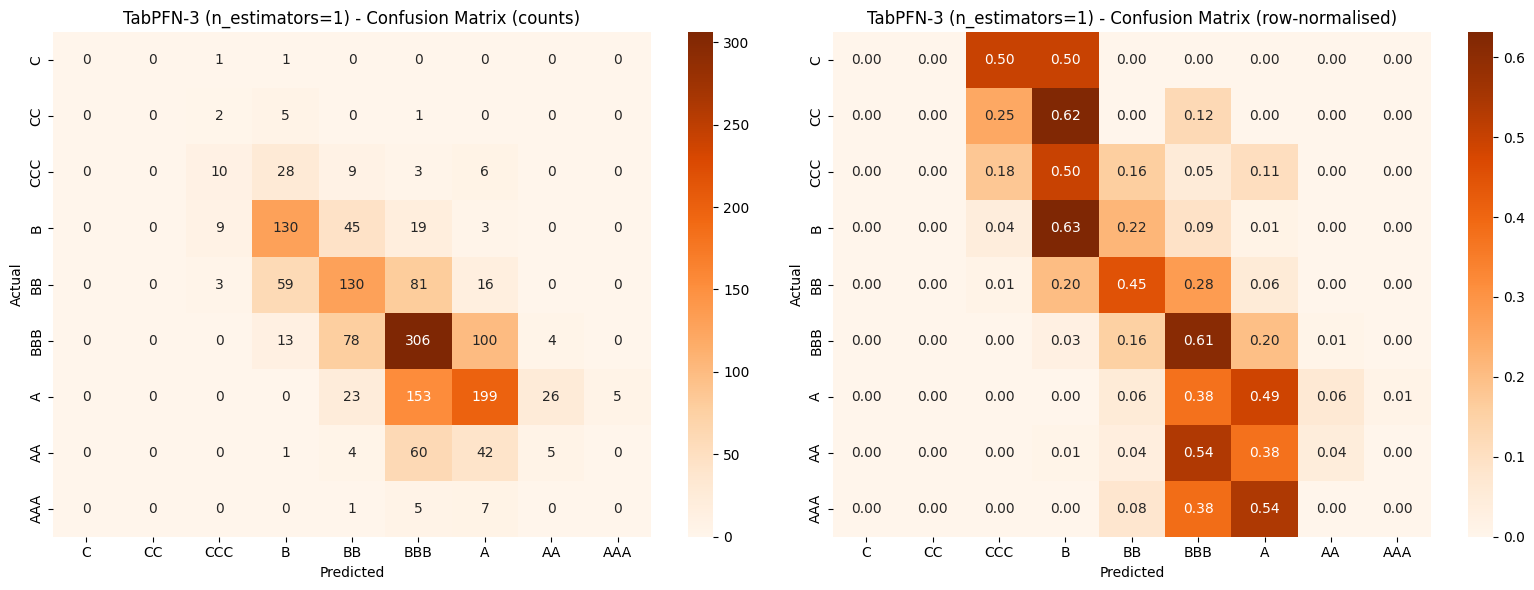

Saved confusion matrix -> /content/Thesis-Artifact/outputs/tabpfn3_confusion_matrix.png


In [ ]:
plotting.plot_confusion_pair(y_test, y_pred, f'TabPFN-3 (n_estimators={best_n})',
    cmap='Oranges', save_path=config.OUTPUTS_DIR/'tabpfn3_confusion_matrix.png')

## Permutation feature importance

Since TabPFN is a transformer-based model, it does not provide built-in feature importance scores like XGBoost does. Instead, we use **permutation importance**: for each feature, we randomly shuffle its values in the test set and measure how much the F1 macro score drops. A large drop means the feature is important — the model relied on it heavily.

This process is repeated 10 times per feature to get stable estimates. Note that this is computationally expensive as it requires re-running inference many times.

The ranking may differ from XGBoost's built-in importance because the two methods measure different things: XGBoost measures how often a feature is used in splits, while permutation importance measures how much performance degrades without it.

In [ ]:
from sklearn.inspection import permutation_importance

print('Computing permutation importance...')
perm = permutation_importance(clf, X_test, y_test, n_repeats=10,
    scoring='f1_macro', random_state=config.RANDOM_STATE, n_jobs=-1)
feat_imp = pd.Series(perm.importances_mean, index=X_test.columns)
plotting.plot_feature_importance(feat_imp, 'TabPFN-3', color='darkorange',
    save_path=config.OUTPUTS_DIR/'tabpfn3_feature_importance.png')

Computing permutation importance (this may take a few minutes)...


## Summary

TabPFN-3 achieves the strongest performance of the three models despite requiring no traditional training — it processes the dataset in a single forward pass through a pre-trained transformer. The `n_estimators` experiment reveals that additional ensembling provides no benefit on this low-dimensional dataset.

Results are saved to `outputs/tabpfn3_results.pkl` for comparison with XGBoost (notebook 2) and AutoGluon (notebook 4).